# Task 07 - Explainable AI Analysis

**Target Task:** Option C - Disease Risk Classification

**Author:** Nuwani (Task 7 & 8)

This section explains the predictions made by the best performing model, Logistic Regression, which was selected in Task 6. SHAP and LIME are used to understand the model’s predictions, including overall feature importance and individual patient-level decisions.

A simple Streamlit prototype is also created to allow users to enter patient details and get a predicted disease risk level. The trained model and required preprocessing artifacts are saved for use in the prototype.

## 7.1 Import SHAP

SHAP is used to explain the Logistic Regression model because Task 6 identified it as the best-performing model overall, with the highest test macro-F1 score. Since Logistic Regression is a linear model, no proxy model is needed. This also allows SHAP to use the LinearExplainer, which provides fast and exact explanations for the model.

In [ ]:
!pip install shap -q
import shap
shap.initjs()

## 7.2 Build Explainer and Compute SHAP Values

In [ ]:
# Logistic Regression was trained on SCALED features (Task 05) and is the best model (Task 06)
explain_model = models['Logistic Regression']

X_train_scaled_numeric = X_train_scaled.astype(float)
X_test_scaled_numeric = X_test_scaled.astype(float)
X_train_array = X_train_scaled_numeric.to_numpy(dtype='float64')
X_test_array = X_test_scaled_numeric.to_numpy(dtype='float64')

background = shap.sample(X_train_array, 100, random_state=RANDOM_STATE)
explainer = shap.LinearExplainer(explain_model, background)
shap_values = explainer.shap_values(X_test_array)

class_labels = CLASS_LABELS
print("Classes:", class_labels)

Classes: ['Low', 'Medium', 'High']


## 7.3 Global Explanation – Summary Plot

The beeswarm plot below shows which features have the most influence on predictions of 'High' disease risk and whether they increase or decrease the prediction.

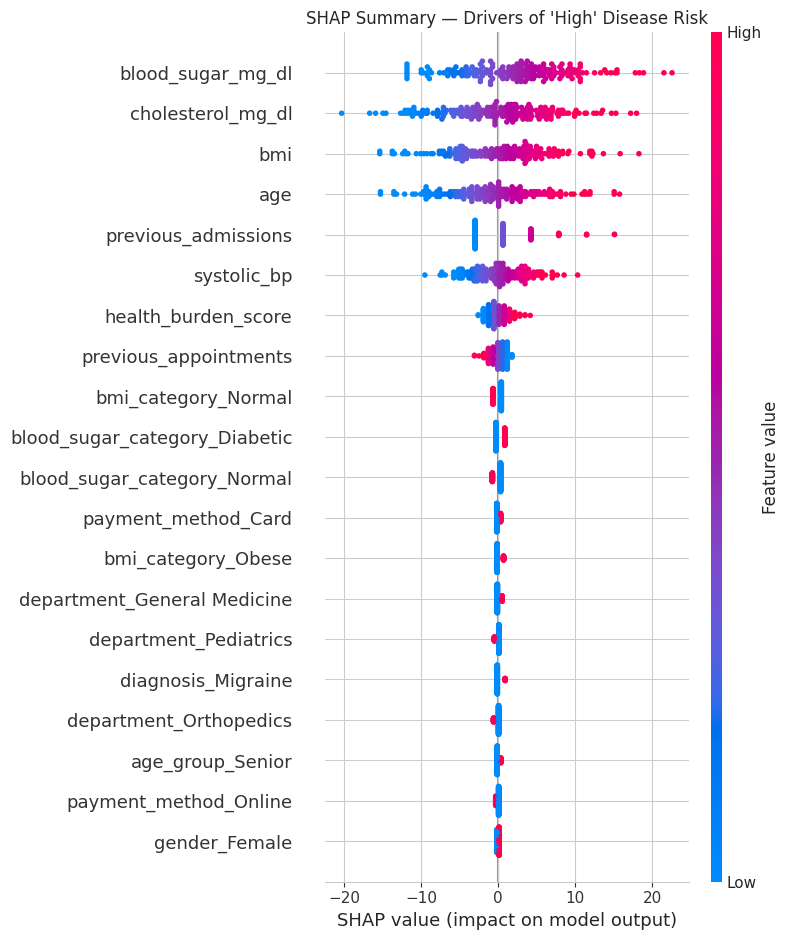

In [ ]:
high_idx = class_labels.index('High')

plt.figure()
shap.summary_plot(
    shap_values[:, :, high_idx],
    X_test_array,
    feature_names=X_test_scaled_numeric.columns.tolist(),
    show=False
)
plt.title("SHAP Summary — Drivers of 'High' Disease Risk")
plt.tight_layout()
plt.show()

The main features affecting High-risk predictions are blood_sugar_mg_dl, cholesterol_mg_dl, bmi, age, and previous_admissions. High blood sugar, cholesterol, and BMI increase the prediction toward High risk. Higher age and previous admissions have a smaller effect in the opposite direction. This may be because age_group already captures the main effect of age.

## 7.4 Global Explanation – Feature Importance Across Classes

This bar chart shows the average feature importance for all three risk classes.


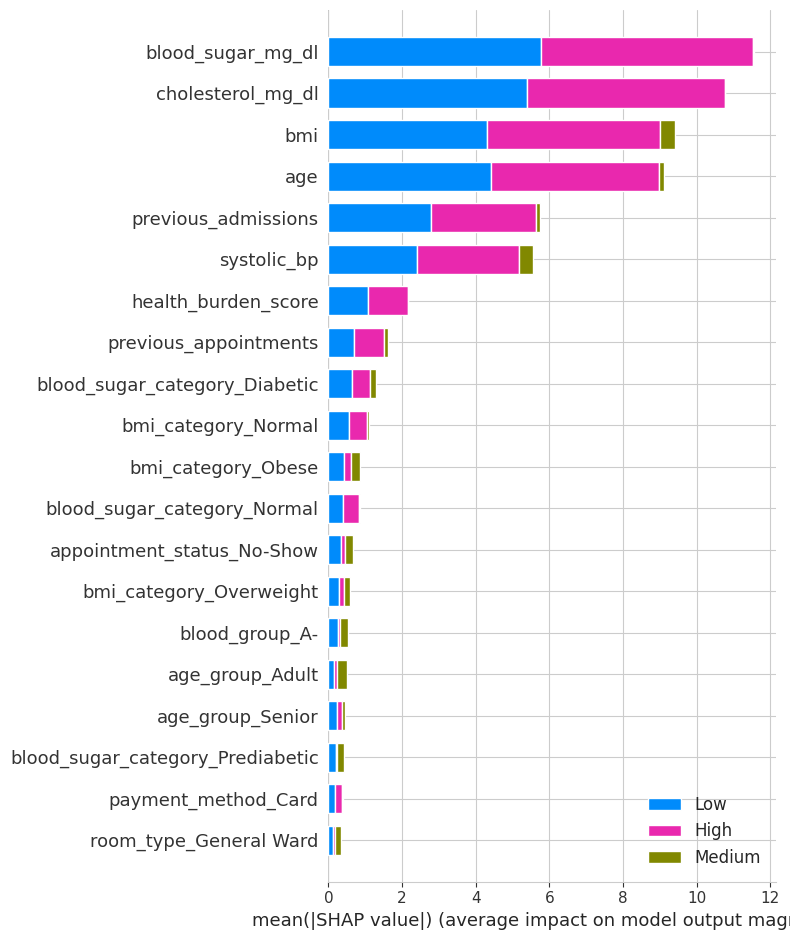

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test_scaled_numeric, feature_names=X_test_scaled_numeric.columns, class_names=class_labels, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

The same five clinical features are the most important across all three risk classes. blood_sugar_mg_dl has the strongest overall influence. The Medium risk class has much less feature influence, suggesting that the model can separate Low and High risk more easily than Medium risk. The engineered and administrative features have only a small effect.

## 7.5 Local Explanations - Individual Predictions

The waterfall plots below explain individual predictions: one correctly predicted High-risk patient, one correctly predicted Low-risk patient, and one misclassified case.


Correctly predicted High — predicted: High, actual: High


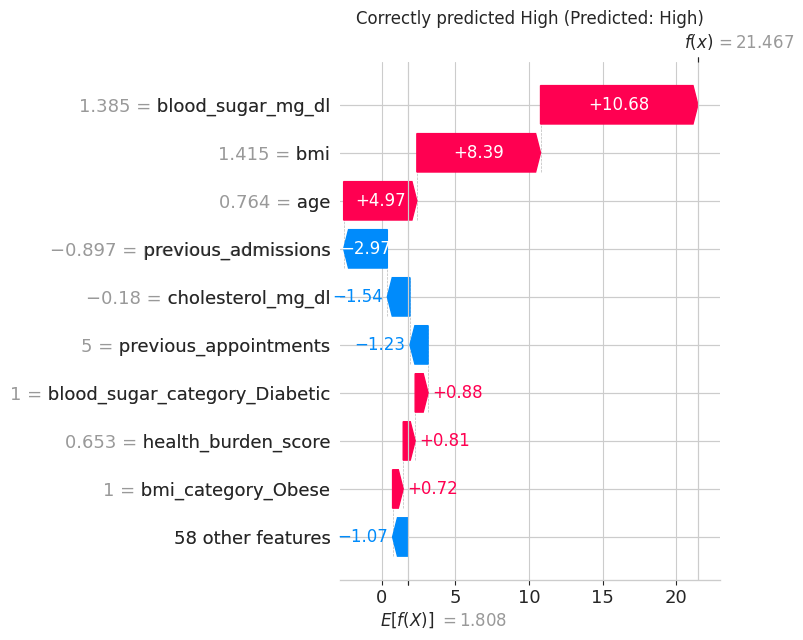


Correctly predicted Low — predicted: Low, actual: Low


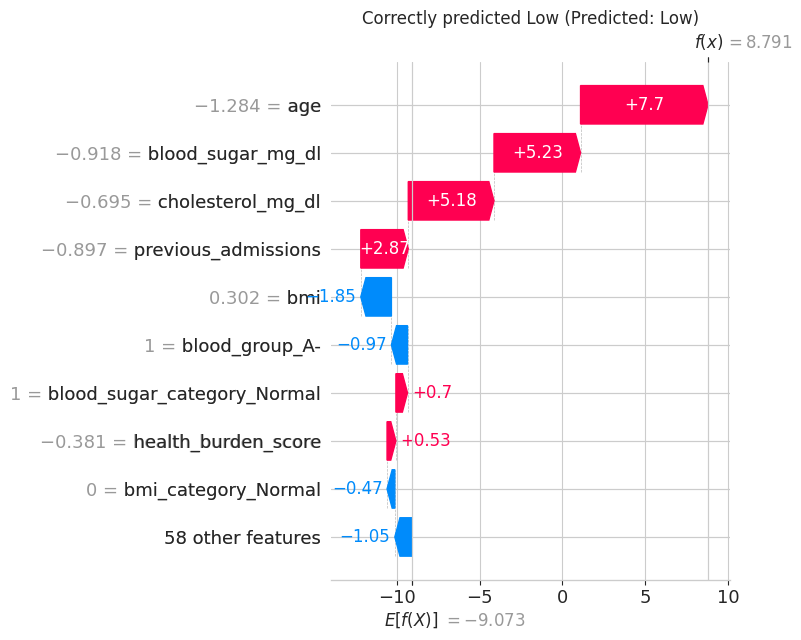


Misclassified case — predicted: High, actual: Medium


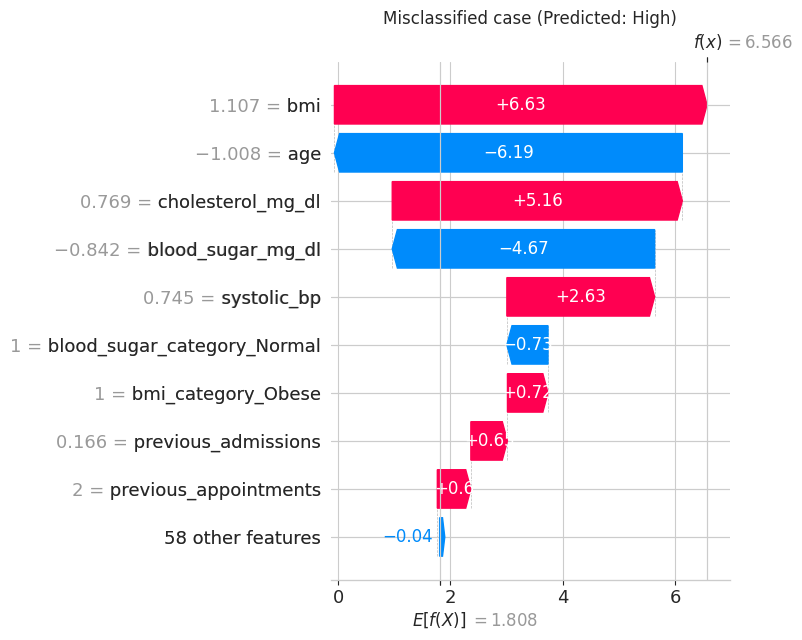

In [ ]:
y_pred_lr = predictions['Logistic Regression']
y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test

correct_high_idx = np.where((y_test_arr == class_labels.index('High')) & (y_pred_lr == class_labels.index('High')))[0][0]
correct_low_idx  = np.where((y_test_arr == class_labels.index('Low'))  & (y_pred_lr == class_labels.index('Low')))[0][0]
misclassified = np.where(y_test_arr != y_pred_lr)[0]
wrong_idx = misclassified[0] if len(misclassified) else correct_high_idx

for label, idx in [("Correctly predicted High", correct_high_idx),
                    ("Correctly predicted Low", correct_low_idx),
                    ("Misclassified case", wrong_idx)]:
    predicted_class = y_pred_lr[idx]
    print(f"\n{label} — predicted: {class_labels[predicted_class]}, actual: {class_labels[y_test_arr[idx]]}")
    explanation = shap.Explanation(
        values=shap_values[idx, :, predicted_class],
        base_values=explainer.expected_value[predicted_class],
        data=X_test_scaled_numeric.iloc[idx],
        feature_names=X_test_scaled_numeric.columns.tolist()
    )
    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"{label} (Predicted: {class_labels[predicted_class]})")
    plt.tight_layout()
    plt.show()

For correctly predicted cases, the important features usually agree with each other. For example, younger age and low blood sugar both support a Low-risk prediction. In the misclassified case, the features conflict with each other. High BMI and cholesterol push the prediction toward High, while low age and blood sugar push it toward Medium. These conflicting signals explain why the model made the wrong prediction.

## 7.6 SHAP Dependence Plots - Feature Interaction Effects

<Figure size 800x500 with 0 Axes>

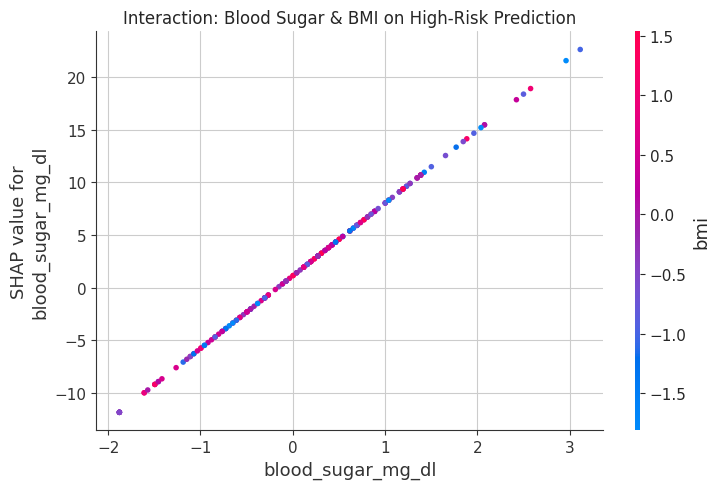

<Figure size 800x500 with 0 Axes>

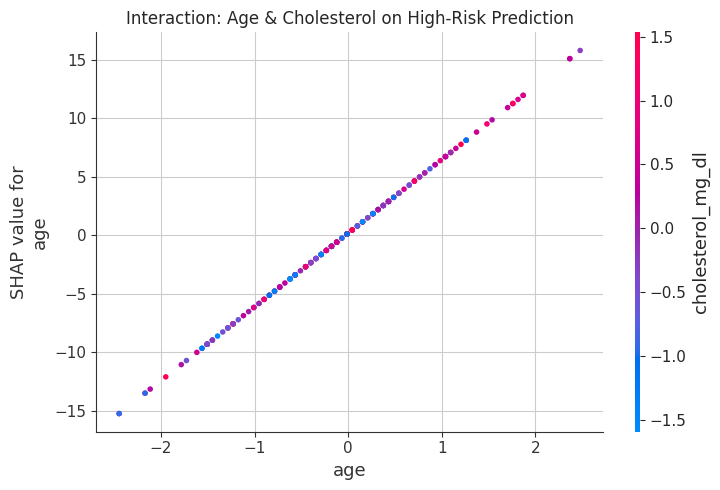

In [ ]:
high_idx = class_labels.index('High')

plt.figure()
shap.dependence_plot(
    "blood_sugar_mg_dl", shap_values[:, :, high_idx], X_test_scaled_numeric,
    feature_names=X_test_scaled_numeric.columns.tolist(), interaction_index="bmi", show=False
)
plt.title("Interaction: Blood Sugar & BMI on High-Risk Prediction")
plt.tight_layout()
plt.show()

plt.figure()
shap.dependence_plot(
    "age", shap_values[:, :, high_idx], X_test_scaled_numeric,
    feature_names=X_test_scaled_numeric.columns.tolist(), interaction_index="cholesterol_mg_dl", show=False
)
plt.title("Interaction: Age & Cholesterol on High-Risk Prediction")
plt.tight_layout()
plt.show()

Both dependence plots show clear straight-line relationships, which is expected from Logistic Regression because its predictions are linear and additive. There are no clear interaction effects.

For example, BMI does not noticeably change the blood sugar relationship, and cholesterol does not change the age relationship. This means the model mainly considers each feature separately rather than learning complex feature combinations.

## BONUS PART

## 7.7 LIME - Cross-Validation of SHAP Explanations

In [ ]:
!pip install lime -q
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled_numeric.values,
    feature_names=X_train_scaled_numeric.columns.tolist(),
    class_names=class_labels,
    mode='classification',
    random_state=RANDOM_STATE
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled_numeric.iloc[wrong_idx].values,
    explain_model.predict_proba,
    num_features=10,
    top_labels=1
)
lime_exp.show_in_notebook(show_table=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


LIME gives a similar explanation to SHAP for the same misclassified case. Both methods identify the same top five features and show a similar ranking and direction of effect. LIME's confidence was 67% High vs. 33% Medium, showing that this was a borderline case rather than a confident mistake. The agreement between SHAP and LIME increases confidence that these features are the main factors driving the model's predictions.

## 7.8 Interpretation and Ethical Implications

**Transparency:** Logistic Regression is easy to understand because its predictions are based on the weighted values of the features. SHAP's LinearExplainer provides exact SHAP values rather than approximate values. This helps clinicians clearly see which patient measurements influenced the prediction, instead of using a black-box model where explanations are only given after the prediction.


**Ethical implications:** The misclassified case was a close prediction (67% High vs. 33% Medium), rather than a highly confident error. This shows that the model should be used to support clinical review, not to replace clinical judgement. There are two main risks: clinicians may trust a "High Risk" label too much without checking the probability, and missing a truly high-risk patient is more serious than giving a false warning. To reduce this risk, the prototype shows the full class probabilities instead of only the predicted label.

# Task 08 - AI Prototype Development



## 8.1 Save the model artifacts

In [ ]:
import joblib

# best_model = Logistic Regression (Task 06), trained on X_train_scaled (Task 05)
joblib.dump(best_model, 'disease_risk_model.pkl')

# scaler was fit in Task 03 on a specific 8-column subset only - save it as-is
joblib.dump(scaler, 'scaler.pkl')

# No LabelEncoder dict exists - Task 03 used one-hot encoding (pd.get_dummies).
# Save each nominal column's category set so the prototype can rebuild the same dummy columns for new patient input.
nominal_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'room_type',
                 'payment_method', 'payment_status', 'appointment_status',
                 'bp_category', 'bmi_category', 'blood_sugar_category', 'age_group']
category_values = {col: sorted(df[col].dropna().unique().tolist()) for col in nominal_cols}
joblib.dump(category_values, 'category_values.pkl')

# No target_encoder object exists - Task 03 used a manual ordinal map instead
risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
joblib.dump(risk_order, 'target_encoding.pkl')

# Exact feature columns/order the model expects - cast to match the dtype-clean float format used for SHAP in Task 7, so the prototype builds input consistently
X_train_scaled_numeric = X_train_scaled.astype(float)
joblib.dump(X_train_scaled_numeric.columns.tolist(), 'feature_columns.pkl')

# Numeric columns the scaler transforms - everything else (one-hot columns) passes through unscaled
joblib.dump(numeric_cols_to_scale, 'numeric_cols_to_scale.pkl')

!cp disease_risk_model.pkl scaler.pkl category_values.pkl target_encoding.pkl feature_columns.pkl numeric_cols_to_scale.pkl /content/drive/MyDrive/SmartCare/

## 8.2 Working Prototype

The AI-powered prototype is a Streamlit web app (prototype/app.py) that uses the trained model and saved artifacts. It allows users to enter patient details through a form. The app then applies the same encoding and scaling used during training and predicts the patient's risk level. It also shows the confidence/probability for all three classes. The prototype can be run locally from the prototype/ folder using **streamlit run app.py**.